In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/clean_transactions.csv")

print("Shape:", df.shape)
df.head()

Shape: (536642, 18)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,DayOfWeek,TransactionType,IsCancellation,IsNegativeQuantity,IsZeroPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Wednesday,SALE,False,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday,SALE,False,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Wednesday,SALE,False,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday,SALE,False,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday,SALE,False,False,False


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 536642 entries, 0 to 536641
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Invoice             536642 non-null  str    
 1   StockCode           536642 non-null  str    
 2   Description         535188 non-null  str    
 3   Quantity            536642 non-null  int64  
 4   InvoiceDate         536642 non-null  str    
 5   Price               536642 non-null  float64
 6   Customer ID         401605 non-null  float64
 7   Country             536642 non-null  str    
 8   Revenue             536642 non-null  float64
 9   Year                536642 non-null  int64  
 10  Month               536642 non-null  int64  
 11  Day                 536642 non-null  int64  
 12  Hour                536642 non-null  int64  
 13  DayOfWeek           536642 non-null  str    
 14  TransactionType     536642 non-null  str    
 15  IsCancellation      536642 non-null  bool   


In [3]:
print("Transaction Types:")
print(df["TransactionType"].value_counts())

print("\nCustomer ID coverage:")
print("With Customer ID:", df["Customer ID"].notna().sum())
print("Without Customer ID:", df["Customer ID"].isna().sum())

print("\nRevenue nulls:", df["Revenue"].isna().sum())

Transaction Types:
TransactionType
SALE                              524559
CANCELLATION                        8975
RETURN_OR_NEGATIVE_TRANSACTION      1336
ZERO_PRICE_TRANSACTION              1168
MANUAL_ADJUSTMENT                    567
AMAZON_FEE                            34
BAD_DEBT_ADJUSTMENT                    3
Name: count, dtype: int64

Customer ID coverage:
With Customer ID: 401605
Without Customer ID: 135037

Revenue nulls: 0


## Overall Business Analytics

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


In [5]:
sales_df = df[df["TransactionType"] == "SALE"].copy()

print("Total rows:", len(df))
print("Sales rows:", len(sales_df))
print("Non-sales rows:", len(df) - len(sales_df))

Total rows: 536642
Sales rows: 524559
Non-sales rows: 12083


In [6]:
total_sales = sales_df["Revenue"].sum()
total_units = sales_df["Quantity"].sum()
unique_orders = sales_df["Invoice"].nunique()
unique_products = sales_df["StockCode"].nunique()
unique_customers = sales_df["Customer ID"].nunique()

print("Total Sales Revenue: £{:,.2f}".format(total_sales))
print("Total Units Sold:", f"{total_units:,}")
print("Unique Orders:", f"{unique_orders:,}")
print("Unique Products:", f"{unique_products:,}")
print("Unique Customers:", f"{unique_customers:,}")

Total Sales Revenue: £10,539,552.83
Total Units Sold: 5,565,433
Unique Orders: 19,865
Unique Products: 3,918
Unique Customers: 4,335


In [7]:
order_revenue = sales_df.groupby("Invoice")["Revenue"].sum()

average_order_value = order_revenue.mean()

print("Average Order Value: £{:,.2f}".format(average_order_value))

Average Order Value: £530.56


In [8]:
cancellation_df = df[df["TransactionType"] == "CANCELLATION"].copy()

cancellation_value = cancellation_df["Revenue"].sum()

print("Cancellation Transactions:", f"{len(cancellation_df):,}")
print("Cancellation Value: £{:,.2f}".format(cancellation_value))

Cancellation Transactions: 8,975
Cancellation Value: £-511,913.68


In [9]:
net_product_revenue = total_sales + cancellation_value

print("Gross Sales Revenue: £{:,.2f}".format(total_sales))
print("Cancellation Value: £{:,.2f}".format(cancellation_value))
print("Net Product Revenue: £{:,.2f}".format(net_product_revenue))

Gross Sales Revenue: £10,539,552.83
Cancellation Value: £-511,913.68
Net Product Revenue: £10,027,639.15


In [10]:
monthly_sales = (
    sales_df
    .groupby(["Year", "Month"])
    .agg(
        Revenue=("Revenue", "sum"),
        Units_Sold=("Quantity", "sum"),
        Orders=("Invoice", "nunique")
    )
    .reset_index()
)

monthly_sales["YearMonth"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str) + "-01"
)

monthly_sales = monthly_sales.sort_values("YearMonth")

monthly_sales

,Year,Month,Revenue,Units_Sold,Orders,YearMonth
0,2010,12,805431.140,357816,1554,2010-12-01
1,2011,1,689714.710,387058,1084,2011-01-01
2,2011,2,521308.110,282848,1094,2011-02-01
3,2011,3,707759.120,376504,1444,2011-03-01
4,2011,4,526859.991,307848,1239,2011-04-01
5,2011,5,764075.380,394977,1672,2011-05-01
6,2011,6,755619.130,388467,1529,2011-06-01
7,2011,7,706968.321,399589,1457,2011-07-01
8,2011,8,743467.280,420988,1355,2011-08-01
9,2011,9,1050350.002,569051,1832,2011-09-01


In [11]:
monthly_sales["Average_Order_Value"] = (
    monthly_sales["Revenue"] / monthly_sales["Orders"]
)

monthly_sales

,Year,Month,Revenue,Units_Sold,Orders,YearMonth,Average_Order_Value
0,2010,12,805431.140,357816,1554,2010-12-01,518.295457
1,2011,1,689714.710,387058,1084,2011-01-01,636.268183
2,2011,2,521308.110,282848,1094,2011-02-01,476.515640
3,2011,3,707759.120,376504,1444,2011-03-01,490.137895
4,2011,4,526859.991,307848,1239,2011-04-01,425.230017
5,2011,5,764075.380,394977,1672,2011-05-01,456.982883
6,2011,6,755619.130,388467,1529,2011-06-01,494.191714
7,2011,7,706968.321,399589,1457,2011-07-01,485.221909
8,2011,8,743467.280,420988,1355,2011-08-01,548.684339
9,2011,9,1050350.002,569051,1832,2011-09-01,573.335154


In [12]:
best_month = monthly_sales.loc[
    monthly_sales["Revenue"].idxmax()
]

worst_month = monthly_sales.loc[
    monthly_sales["Revenue"].idxmin()
]

print("Best month:")
print(best_month)

print("\nLowest revenue month:")
print(worst_month)

Best month:
Year                                  2011
Month                                   11
Revenue                         1500554.36
Units_Sold                          747486
Orders                                2761
YearMonth              2011-11-01 00:00:00
Average_Order_Value             543.482202
Name: 11, dtype: object

Lowest revenue month:
Year                                  2011
Month                                    2
Revenue                          521308.11
Units_Sold                          282848
Orders                                1094
YearMonth              2011-02-01 00:00:00
Average_Order_Value              476.51564
Name: 2, dtype: object


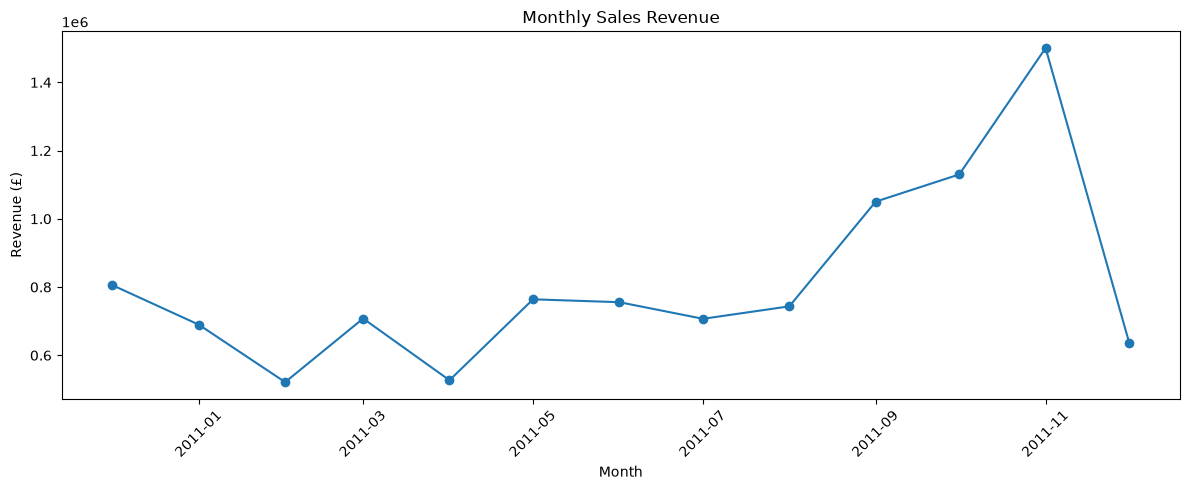

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Customer Analytics

In [14]:
customer_df = sales_df[sales_df["Customer ID"].notna()].copy()

print("Sales transactions:", len(sales_df))
print("Transactions with Customer ID:", len(customer_df))
print("Unique customers:", customer_df["Customer ID"].nunique())

Sales transactions: 524559
Transactions with Customer ID: 392414
Unique customers: 4335


In [15]:
customer_summary = (
    customer_df
    .groupby("Customer ID")
    .agg(
        Orders=("Invoice", "nunique"),
        Total_Items=("Quantity", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Unique_Products=("StockCode", "nunique"),
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_summary.head()

,Customer ID,Orders,Total_Items,Total_Revenue,Unique_Products,First_Purchase,Last_Purchase
0,12346.0,1,74215,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,7,2458,4310.00,103,2010-12-07 14:57:00,2011-12-07 15:52:00
2,12348.0,4,2341,1797.24,22,2010-12-16 19:09:00,2011-09-25 13:13:00
3,12349.0,1,631,1757.55,73,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350.0,1,197,334.40,17,2011-02-02 16:01:00,2011-02-02 16:01:00


In [16]:
customer_summary["Average_Order_Value"] = (
    customer_summary["Total_Revenue"] /
    customer_summary["Orders"]
)

customer_summary.head()

,Customer ID,Orders,Total_Items,Total_Revenue,Unique_Products,First_Purchase,Last_Purchase,Average_Order_Value
0,12346.0,1,74215,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000
1,12347.0,7,2458,4310.00,103,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286
2,12348.0,4,2341,1797.24,22,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000
3,12349.0,1,631,1757.55,73,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000
4,12350.0,1,197,334.40,17,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000


In [17]:
top_customers = (
    customer_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_customers

,Customer ID,Orders,Total_Items,Total_Revenue,Unique_Products,First_Purchase,Last_Purchase,Average_Order_Value
1689,14646.0,73,196915,280206.02,700,2010-12-20 10:09:00,2011-12-08 12:12:00,3838.438630
4198,18102.0,60,64124,259657.30,150,2010-12-07 16:42:00,2011-12-09 11:50:00,4327.621667
3726,17450.0,46,69973,194390.79,124,2010-12-07 09:23:00,2011-12-01 13:29:00,4225.886739
3007,16446.0,2,80997,168472.50,3,2011-05-18 09:52:00,2011-12-09 09:15:00,84236.250000
1879,14911.0,199,80238,140336.83,1786,2010-12-01 14:05:00,2011-12-08 15:54:00,705.210201
55,12415.0,21,77374,124914.53,444,2011-01-06 11:12:00,2011-11-15 14:22:00,5948.310952
1333,14156.0,55,57768,117210.08,714,2010-12-03 11:48:00,2011-11-30 10:54:00,2131.092364
3769,17511.0,31,64549,91062.38,453,2010-12-01 10:19:00,2011-12-07 10:12:00,2937.496129
2701,16029.0,63,40108,80850.84,44,2010-12-01 09:57:00,2011-11-01 10:27:00,1283.346667
0,12346.0,1,74215,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000


In [18]:
analysis_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 12:50:00


In [19]:
rfm = (
    customer_df
    .groupby("Customer ID")
    .agg(
        Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [20]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4335.000000,4335.000000,4335.000000
mean,92.678662,4.260208,2037.787074
std,100.203903,7.659946,8966.232164
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.290000
50%,51.000000,2.000000,668.560000
75%,143.000000,5.000000,1651.605000
max,374.000000,206.000000,280206.020000


In [21]:
print("Most recent customers:")
display(rfm.sort_values("Recency").head(10))

print("\nMost frequent customers:")
display(rfm.sort_values("Frequency", ascending=False).head(10))

print("\nHighest monetary customers:")
display(rfm.sort_values("Monetary", ascending=False).head(10))

Most recent customers:


,Customer ID,Recency,Frequency,Monetary
1143,13890.0,1,10,1883.81
326,12748.0,1,206,31654.78
3953,17757.0,1,30,5589.44
3291,16833.0,1,4,1106.53
934,13599.0,1,21,5149.92
71,12433.0,1,7,13375.87
892,13536.0,1,7,3444.39
3331,16892.0,1,5,518.19
1694,14653.0,1,7,1916.70
3885,17668.0,1,2,347.75



Most frequent customers:


,Customer ID,Recency,Frequency,Monetary
326,12748.0,1,206,31654.78
1879,14911.0,1,199,140336.83
4008,17841.0,2,124,40495.99
562,13089.0,3,97,58762.08
1661,14606.0,1,92,12061.15
2176,15311.0,1,91,60632.75
481,12971.0,4,86,11189.91
1689,14646.0,2,73,280206.02
2701,16029.0,39,63,80850.84
795,13408.0,2,62,28117.04



Highest monetary customers:


,Customer ID,Recency,Frequency,Monetary
1689,14646.0,2,73,280206.02
4198,18102.0,1,60,259657.30
3726,17450.0,8,46,194390.79
3007,16446.0,1,2,168472.50
1879,14911.0,1,199,140336.83
55,12415.0,24,21,124914.53
1333,14156.0,10,55,117210.08
3769,17511.0,3,31,91062.38
2701,16029.0,39,63,80850.84
0,12346.0,326,1,77183.60


In [22]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,1,77183.60,1,1,5
1,12347.0,2,7,4310.00,5,5,5
2,12348.0,75,4,1797.24,2,4,4
3,12349.0,19,1,1757.55,4,1,4
4,12350.0,310,1,334.40,1,1,2


In [23]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,1,77183.60,1,1,5,7
1,12347.0,2,7,4310.00,5,5,5,15
2,12348.0,75,4,1797.24,2,4,4,10
3,12349.0,19,1,1757.55,4,1,4,9
4,12350.0,310,1,334.40,1,1,2,4


In [24]:
rfm["RFM_Score"].value_counts().sort_index()

RFM_Score
3     182
4     362
5     338
6     425
7     371
8     378
9     339
10    342
11    347
12    321
13    282
14    301
15    347
Name: count, dtype: int64

In [25]:
rfm.sort_values(
    ["RFM_Score", "Monetary"],
    ascending=[False, False]
).head(20)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
1689,14646.0,2,73,280206.02,5,5,5,15
4198,18102.0,1,60,259657.30,5,5,5,15
3726,17450.0,8,46,194390.79,5,5,5,15
1879,14911.0,1,199,140336.83,5,5,5,15
1333,14156.0,10,55,117210.08,5,5,5,15
3769,17511.0,3,31,91062.38,5,5,5,15
3175,16684.0,4,28,66653.56,5,5,5,15
1289,14096.0,4,17,65164.79,5,5,5,15
996,13694.0,4,50,65039.62,5,5,5,15
2176,15311.0,1,91,60632.75,5,5,5,15


In [26]:
def segment_customer(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "Recent Customers"

    elif r >= 3 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    elif r <= 2 and f >= 3:
        return "Need Attention"

    elif r <= 2 and f <= 2 and m >= 3:
        return "High Value At Risk"

    else:
        return "Lost Customers"


rfm["Customer_Segment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,12346.0,326,1,77183.60,1,1,5,7,High Value At Risk
1,12347.0,2,7,4310.00,5,5,5,15,Champions
2,12348.0,75,4,1797.24,2,4,4,10,At Risk
3,12349.0,19,1,1757.55,4,1,4,9,Recent Customers
4,12350.0,310,1,334.40,1,1,2,4,Lost Customers


In [27]:
segment_counts = (
    rfm["Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Customer_Segment", "Customers"]

segment_counts

,Customer_Segment,Customers
0,Loyal Customers,1006
1,Champions,954
2,Lost Customers,823
3,At Risk,453
4,Potential Loyalists,349
5,Recent Customers,320
6,High Value At Risk,242
7,Need Attention,188


In [28]:
segment_revenue = (
    rfm.groupby("Customer_Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Total_Revenue=("Monetary", "sum"),
        Average_Revenue=("Monetary", "mean"),
        Average_Frequency=("Frequency", "mean"),
        Average_Recency=("Recency", "mean")
    )
    .sort_values("Total_Revenue", ascending=False)
    .reset_index()
)

segment_revenue

,Customer_Segment,Customers,Total_Revenue,Average_Revenue,Average_Frequency,Average_Recency
0,Champions,954,5765056.430,6043.036090,11.107966,12.779874
1,Loyal Customers,1006,1452939.891,1444.274246,3.702783,34.103380
2,At Risk,453,732533.752,1617.072300,3.788079,141.724062
3,High Value At Risk,242,328649.080,1358.054050,1.293388,185.061983
4,Lost Customers,823,187785.441,228.171860,1.042527,228.476306
5,Potential Loyalists,349,162968.430,466.958252,1.154728,53.550143
6,Recent Customers,320,146069.910,456.468469,1.243750,18.550000
7,Need Attention,188,57804.030,307.468245,2.436170,178.803191


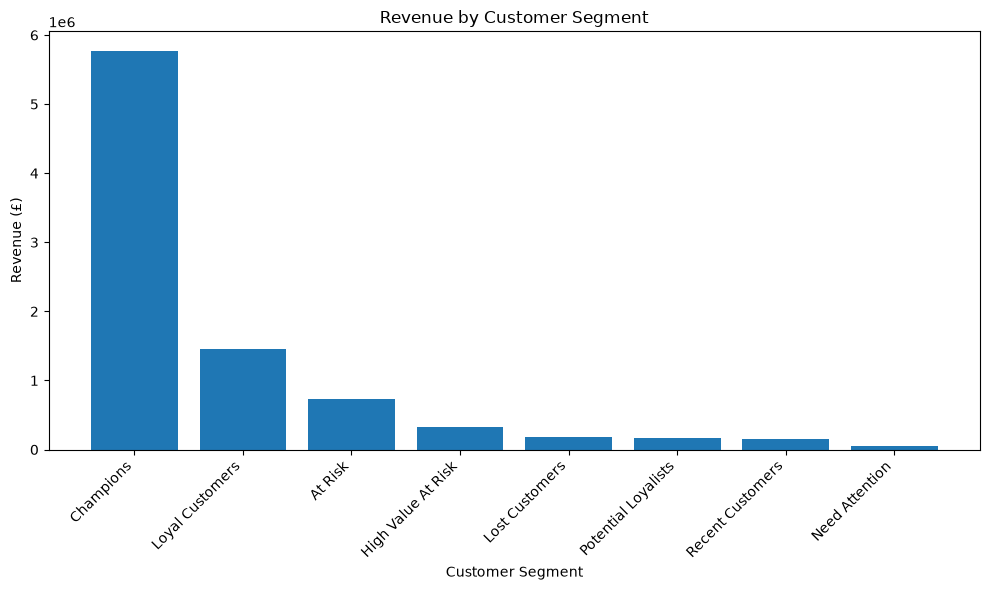

In [29]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_revenue["Customer_Segment"],
    segment_revenue["Total_Revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [30]:
product_sales = sales_df.copy()

print("Sales rows:", len(product_sales))
print("Unique products:", product_sales["StockCode"].nunique())

Sales rows: 524559
Unique products: 3918


In [31]:
product_summary = (
    product_sales
    .groupby("StockCode")
    .agg(
        Product_Name=("Description", "first"),
        Units_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique"),
        Average_Price=("Price", "mean")
    )
    .reset_index()
)

product_summary.head()

,StockCode,Product_Name,Units_Sold,Revenue,Orders,Customers,Average_Price
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,71,40,1.086620
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,22,19,0.410909
2,10120,DOGGY RUBBER,192,40.32,29,25,0.210000
3,10123C,HEARTS WRAPPING TAPE,5,3.25,3,3,0.650000
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16,6.72,5,5,0.420000


In [32]:
product_summary["Product_Name"] = (
    product_summary["Product_Name"]
    .fillna("Unknown Product")
)

product_summary.head()

,StockCode,Product_Name,Units_Sold,Revenue,Orders,Customers,Average_Price
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,71,40,1.086620
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,22,19,0.410909
2,10120,DOGGY RUBBER,192,40.32,29,25,0.210000
3,10123C,HEARTS WRAPPING TAPE,5,3.25,3,3,0.650000
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16,6.72,5,5,0.420000


In [33]:
product_summary["Revenue_Per_Order"] = (
    product_summary["Revenue"] /
    product_summary["Orders"]
)

product_summary.head()

,StockCode,Product_Name,Units_Sold,Revenue,Orders,Customers,Average_Price,Revenue_Per_Order
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,71,40,1.086620,10.702676
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,22,19,0.410909,5.413182
2,10120,DOGGY RUBBER,192,40.32,29,25,0.210000,1.390345
3,10123C,HEARTS WRAPPING TAPE,5,3.25,3,3,0.650000,1.083333
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16,6.72,5,5,0.420000,1.344000


In [34]:
top_products_revenue = (
    product_summary
    .sort_values("Revenue", ascending=False)
    .head(20)
)

top_products_revenue

,StockCode,Product_Name,Units_Sold,Revenue,Orders,Customers,Average_Price,Revenue_Per_Order
3909,DOT,DOTCOM POSTAGE,706,206248.77,706,1,292.137068,292.137068
1310,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988,881,13.983936,87.603893
2465,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1,2.080000,168469.600000
3407,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198,856,3.117838,47.526274
2670,47566,PARTY BUNTING,18283,99445.23,1685,708,5.797928,59.017941
3387,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089,635,2.486197,45.074107
2020,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,138,1.468480,330.772955
3911,POST,POSTAGE,3151,78119.88,1127,331,31.064978,69.316664
1942,23084,RABBIT NIGHT LIGHT,30739,66870.03,994,450,2.386401,67.273672
1006,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59,1160,613,3.362331,55.927233


In [35]:
top_products_units = (
    product_summary
    .sort_values("Units_Sold", ascending=False)
    .head(20)
)

top_products_units

,StockCode,Product_Name,Units_Sold,Revenue,Orders,Customers,Average_Price,Revenue_Per_Order
2465,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1,2.080000,168469.600000
2020,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,138,1.468480,330.772955
1109,22197,SMALL POPCORN HOLDER,56898,51334.47,1392,407,1.043554,36.878211
2909,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01,535,307,0.320728,25.820579
3387,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089,635,2.486197,45.074107
3407,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198,856,3.117838,47.526274
439,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,1320,635,0.761206,16.095795
3194,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455,678,1.722575,40.500082
1942,23084,RABBIT NIGHT LIGHT,30739,66870.03,994,450,2.386401,67.273672
1374,22492,MINI PAINT SET VINTAGE,26633,16937.82,380,213,0.785026,44.573211


In [36]:
top_products_orders = (
    product_summary
    .sort_values("Orders", ascending=False)
    .head(20)
)

top_products_orders

,StockCode,Product_Name,Units_Sold,Revenue,Orders,Customers,Average_Price,Revenue_Per_Order
3407,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198,856,3.117838,47.526274
3387,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089,635,2.486197,45.074107
1310,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988,881,13.983936,87.603893
2670,47566,PARTY BUNTING,18283,99445.23,1685,708,5.797928,59.017941
175,20725,LUNCH BAG RED RETROSPOT,19432,35862.36,1565,532,2.131422,22.915246
3194,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455,678,1.722575,40.500082
1109,22197,SMALL POPCORN HOLDER,56898,51334.47,1392,407,1.043554,36.878211
1593,22720,SET OF 3 CAKE TINS PANTRY DESIGN,7483,38108.89,1385,640,5.833714,27.515444
439,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,1320,635,0.761206,16.095795
1276,22383,LUNCH BAG SUKI DESIGN,12518,22486.34,1284,434,2.168208,17.512726


In [37]:
top_products_customers = (
    product_summary
    .sort_values("Customers", ascending=False)
    .head(20)
)

top_products_customers

,StockCode,Product_Name,Units_Sold,Revenue,Orders,Customers,Average_Price,Revenue_Per_Order
1310,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988,881,13.983936,87.603893
3407,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198,856,3.117838,47.526274
2670,47566,PARTY BUNTING,18283,99445.23,1685,708,5.797928,59.017941
3194,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455,678,1.722575,40.500082
1593,22720,SET OF 3 CAKE TINS PANTRY DESIGN,7483,38108.89,1385,640,5.833714,27.515444
3387,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089,635,2.486197,45.074107
439,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,1320,635,0.761206,16.095795
1006,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59,1160,613,3.362331,55.927233
1343,22457,NATURAL SLATE HEART CHALKBOARD,9119,27991.61,1249,587,3.590032,22.411217
1056,22138,BAKING SET 9 PIECE RETROSPOT,4937,24185.27,934,581,5.353145,25.894293


In [38]:
product_summary_sorted = product_summary.sort_values(
    "Revenue",
    ascending=False
).reset_index(drop=True)

product_summary_sorted["Cumulative_Revenue"] = (
    product_summary_sorted["Revenue"].cumsum()
)

total_product_revenue = product_summary_sorted["Revenue"].sum()

product_summary_sorted["Cumulative_Revenue_Pct"] = (
    product_summary_sorted["Cumulative_Revenue"] /
    total_product_revenue * 100
)

product_summary_sorted.head(20)

,StockCode,Product_Name,Units_Sold,Revenue,Orders,Customers,Average_Price,Revenue_Per_Order,Cumulative_Revenue,Cumulative_Revenue_Pct
0,DOT,DOTCOM POSTAGE,706,206248.77,706,1,292.137068,292.137068,206248.77,1.956902
1,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988,881,13.983936,87.603893,380405.31,3.609312
2,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1,2.080000,168469.600000,548874.91,5.207763
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198,856,3.117838,47.526274,653337.66,6.198913
4,47566,PARTY BUNTING,18283,99445.23,1685,708,5.797928,59.017941,752782.89,7.142456
5,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089,635,2.486197,45.074107,846942.70,8.035850
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,138,1.468480,330.772955,928643.62,8.811034
7,POST,POSTAGE,3151,78119.88,1127,331,31.064978,69.316664,1006763.50,9.552241
8,23084,RABBIT NIGHT LIGHT,30739,66870.03,994,450,2.386401,67.273672,1073633.53,10.186709
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59,1160,613,3.362331,55.927233,1138509.12,10.802253


In [39]:
products_for_80pct = (
    product_summary_sorted[
        product_summary_sorted["Cumulative_Revenue_Pct"] <= 80
    ]
)

print(
    "Products generating first 80% of revenue:",
    len(products_for_80pct)
)

print(
    "Total products:",
    len(product_summary_sorted)
)

Products generating first 80% of revenue: 806
Total products: 3918


In [40]:
negative_transactions = df[
    df["TransactionType"].isin([
        "CANCELLATION",
        "RETURN_OR_NEGATIVE_TRANSACTION"
    ])
].copy()

print("Negative transaction rows:", len(negative_transactions))

Negative transaction rows: 10311


In [41]:
product_cancellations = (
    negative_transactions
    .groupby("StockCode")
    .agg(
        Cancelled_Units=("Quantity", "sum"),
        Cancellation_Value=("Revenue", "sum"),
        Cancellation_Transactions=("Invoice", "nunique")
    )
    .reset_index()
)

product_cancellations.head()

,StockCode,Cancelled_Units,Cancellation_Value,Cancellation_Transactions
0,10002,-3,0.0,1
1,10123C,-18,0.0,1
2,10123G,-38,0.0,1
3,10133,-92,-4.2,2
4,10134,-19,0.0,1


In [42]:
product_performance = product_summary.merge(
    product_cancellations,
    on="StockCode",
    how="left"
)

product_performance[
    [
        "Cancelled_Units",
        "Cancellation_Value",
        "Cancellation_Transactions"
    ]
] = product_performance[
    [
        "Cancelled_Units",
        "Cancellation_Value",
        "Cancellation_Transactions"
    ]
].fillna(0)

product_performance.head()

,StockCode,Product_Name,Units_Sold,Revenue,Orders,Customers,Average_Price,Revenue_Per_Order,Cancelled_Units,Cancellation_Value,Cancellation_Transactions
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,71,40,1.086620,10.702676,-3.0,0.0,1.0
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,22,19,0.410909,5.413182,0.0,0.0,0.0
2,10120,DOGGY RUBBER,192,40.32,29,25,0.210000,1.390345,0.0,0.0,0.0
3,10123C,HEARTS WRAPPING TAPE,5,3.25,3,3,0.650000,1.083333,-18.0,0.0,1.0
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16,6.72,5,5,0.420000,1.344000,0.0,0.0,0.0


In [43]:
product_performance["Cancellation_Rate"] = (
    product_performance["Cancellation_Transactions"] /
    (
        product_performance["Orders"] +
        product_performance["Cancellation_Transactions"]
    )
)

product_performance["Cancellation_Rate"] = (
    product_performance["Cancellation_Rate"] * 100
)

product_performance.head()

,StockCode,Product_Name,Units_Sold,Revenue,Orders,Customers,Average_Price,Revenue_Per_Order,Cancelled_Units,Cancellation_Value,Cancellation_Transactions,Cancellation_Rate
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,71,40,1.086620,10.702676,-3.0,0.0,1.0,1.388889
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,22,19,0.410909,5.413182,0.0,0.0,0.0,0.000000
2,10120,DOGGY RUBBER,192,40.32,29,25,0.210000,1.390345,0.0,0.0,0.0,0.000000
3,10123C,HEARTS WRAPPING TAPE,5,3.25,3,3,0.650000,1.083333,-18.0,0.0,1.0,25.000000
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16,6.72,5,5,0.420000,1.344000,0.0,0.0,0.0,0.000000


In [44]:
high_cancellation_products = (
    product_performance[
        product_performance["Cancellation_Transactions"] >= 10
    ]
    .sort_values(
        "Cancellation_Rate",
        ascending=False
    )
    .head(20)
)

high_cancellation_products[
    [
        "StockCode",
        "Product_Name",
        "Orders",
        "Cancellation_Transactions",
        "Cancellation_Rate",
        "Revenue"
    ]
]

,StockCode,Product_Name,Orders,Cancellation_Transactions,Cancellation_Rate,Revenue
3912,S,SAMPLES,2,17.0,89.473684,63.050
3900,BANK CHARGES,Bank Charges,11,25.0,69.444444,165.001
1922,23064,CINDERELLA CHANDELIER,23,11.0,32.352941,3717.560
2292,23462,ROCOCO WALL MIRROR WHITE,46,13.0,22.033898,1607.040
1347,22461,SAVOY ART DECO CLOCK,53,14.0,20.895522,1453.580
2469,35004C,SET OF 3 COLOURED FLYING DUCKS,39,10.0,20.408163,1888.100
3444,85159B,"WHITE TEA,COFFEE,SUGAR JARS",59,13.0,18.055556,1134.500
2841,79191C,RETRO PLASTIC ELEPHANT TRAY,65,13.0,16.666667,812.530
1110,22198,LARGE POPCORN HOLDER,86,17.0,16.504854,1870.910
774,21735,TWO DOOR CURIO CABINET,83,14.0,14.432990,2577.450


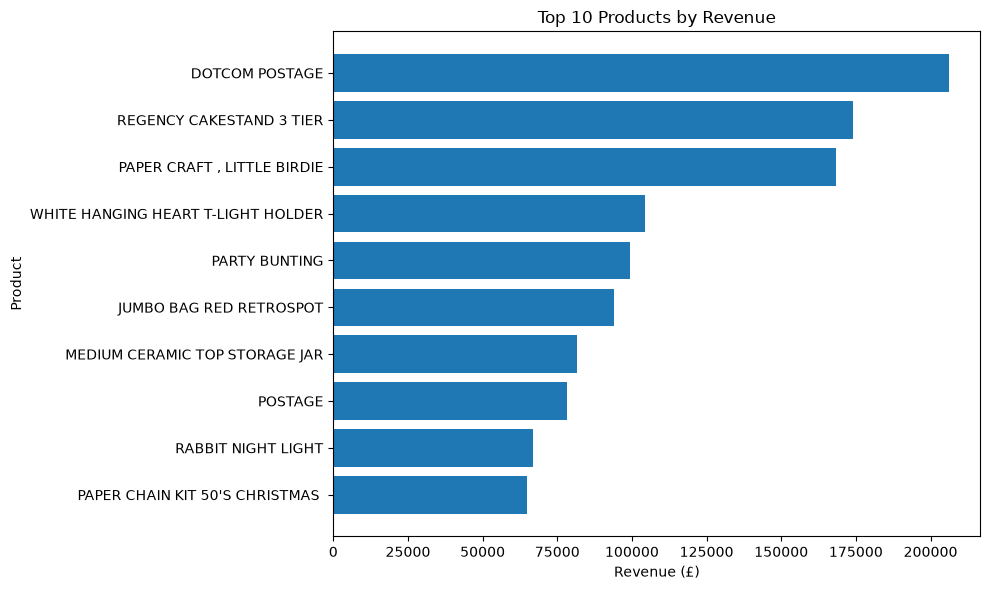

In [45]:
top_10 = (
    product_summary
    .sort_values("Revenue", ascending=False)
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Product_Name"].astype(str),
    top_10["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

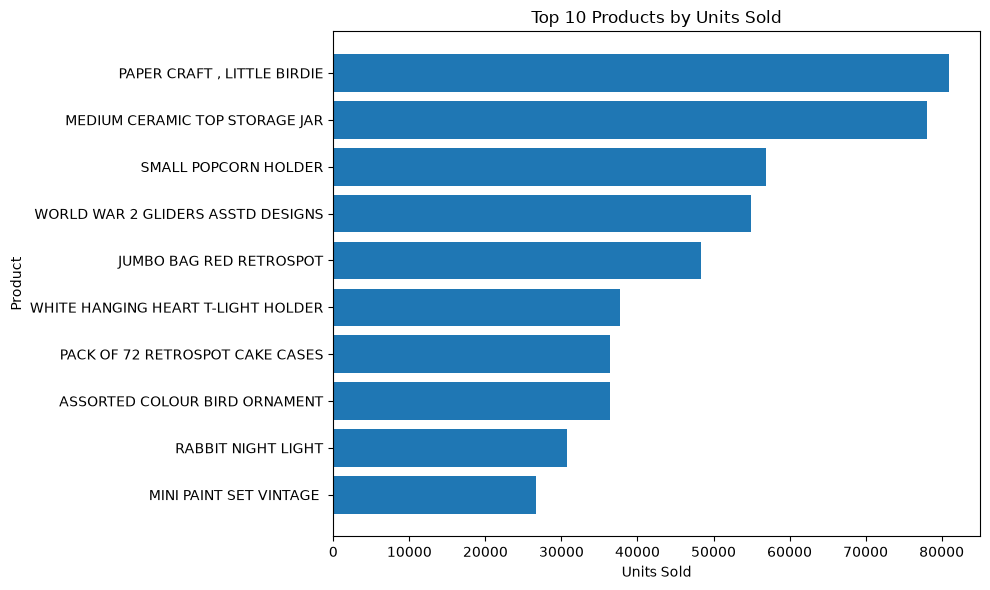

In [46]:
top_10_units = (
    product_summary
    .sort_values("Units_Sold", ascending=False)
    .head(10)
    .sort_values("Units_Sold")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_units["Product_Name"].astype(str),
    top_10_units["Units_Sold"]
)

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [47]:
country_summary = (
    sales_df
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Units_Sold=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
)

country_summary.head()

,Country,Revenue,Units_Sold,Orders,Customers
0,Australia,138453.81,83891,57,9
1,Austria,10198.68,4881,17,11
2,Bahrain,754.14,314,3,2
3,Belgium,41196.34,23237,98,25
4,Brazil,1143.60,356,1,1


In [48]:
country_summary["Average_Order_Value"] = (
    country_summary["Revenue"] /
    country_summary["Orders"]
)

country_summary

,Country,Revenue,Units_Sold,Orders,Customers,Average_Order_Value
0,Australia,138453.810,83891,57,9,2429.014211
1,Austria,10198.680,4881,17,11,599.922353
2,Bahrain,754.140,314,3,2,251.380000
3,Belgium,41196.340,23237,98,25,420.370816
4,Brazil,1143.600,356,1,1,1143.600000
5,Canada,3666.380,2763,6,4,611.063333
6,Channel Islands,20147.540,9484,25,9,805.901600
7,Cyprus,13182.160,6339,15,8,878.810667
8,Czech Republic,826.740,671,2,1,413.370000
9,Denmark,18955.340,8235,18,9,1053.074444


In [49]:
top_countries_revenue = (
    country_summary
    .sort_values("Revenue", ascending=False)
)

top_countries_revenue.head(20)

,Country,Revenue,Units_Sold,Orders,Customers,Average_Order_Value
36,United Kingdom,8941988.244,4639963,17954,3917,498.049919
24,Netherlands,285446.340,200361,94,9,3036.663191
10,EIRE,276090.860,147002,284,3,972.150915
14,Germany,226382.150,119146,451,94,501.955987
13,France,200151.000,112055,388,87,515.853093
0,Australia,138453.810,83891,57,9,2429.014211
31,Spain,61558.560,27933,90,30,683.984000
33,Switzerland,57067.600,30617,54,21,1056.807407
3,Belgium,41196.340,23237,98,25,420.370816
32,Sweden,38337.830,36077,36,8,1064.939722


In [50]:
top_countries_customers = (
    country_summary
    .sort_values("Customers", ascending=False)
)

top_countries_customers.head(20)

,Country,Revenue,Units_Sold,Orders,Customers,Average_Order_Value
36,United Kingdom,8941988.244,4639963,17954,3917,498.049919
14,Germany,226382.150,119146,451,94,501.955987
13,France,200151.000,112055,388,87,515.853093
31,Spain,61558.560,27933,90,30,683.984000
3,Belgium,41196.340,23237,98,25,420.370816
33,Switzerland,57067.600,30617,54,21,1056.807407
27,Portugal,29459.110,16223,52,19,566.521346
19,Italy,17483.240,8112,38,14,460.085263
12,Finland,21994.880,10702,40,12,549.872000
1,Austria,10198.680,4881,17,11,599.922353


In [51]:
top_countries_orders = (
    country_summary
    .sort_values("Orders", ascending=False)
)

top_countries_orders.head(20)

,Country,Revenue,Units_Sold,Orders,Customers,Average_Order_Value
36,United Kingdom,8941988.244,4639963,17954,3917,498.049919
14,Germany,226382.150,119146,451,94,501.955987
13,France,200151.000,112055,388,87,515.853093
10,EIRE,276090.860,147002,284,3,972.150915
3,Belgium,41196.340,23237,98,25,420.370816
24,Netherlands,285446.340,200361,94,9,3036.663191
31,Spain,61558.560,27933,90,30,683.984000
0,Australia,138453.810,83891,57,9,2429.014211
33,Switzerland,57067.600,30617,54,21,1056.807407
27,Portugal,29459.110,16223,52,19,566.521346


In [52]:
total_country_revenue = country_summary["Revenue"].sum()

country_summary["Revenue_Share_Pct"] = (
    country_summary["Revenue"] /
    total_country_revenue * 100
)

country_summary = country_summary.sort_values(
    "Revenue",
    ascending=False
)

country_summary.head(20)

,Country,Revenue,Units_Sold,Orders,Customers,Average_Order_Value,Revenue_Share_Pct
36,United Kingdom,8941988.244,4639963,17954,3917,498.049919,84.842198
24,Netherlands,285446.340,200361,94,9,3036.663191,2.708334
10,EIRE,276090.860,147002,284,3,972.150915,2.619569
14,Germany,226382.150,119146,451,94,501.955987,2.147929
13,France,200151.000,112055,388,87,515.853093,1.899046
0,Australia,138453.810,83891,57,9,2429.014211,1.313659
31,Spain,61558.560,27933,90,30,683.984000,0.584072
33,Switzerland,57067.600,30617,54,21,1056.807407,0.541461
3,Belgium,41196.340,23237,98,25,420.370816,0.390874
32,Sweden,38337.830,36077,36,8,1064.939722,0.363752


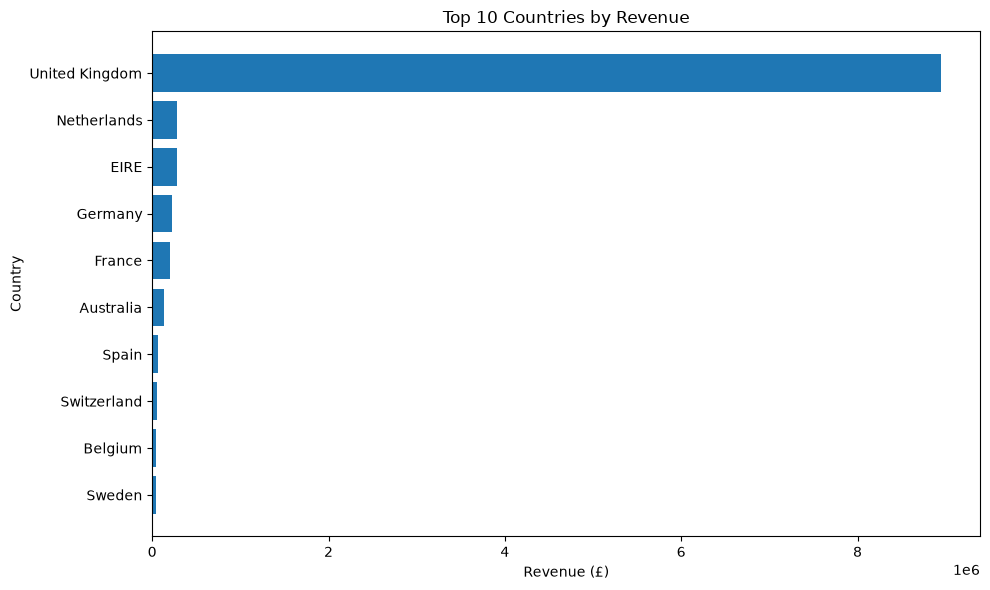

In [53]:
top_10_countries = (
    country_summary
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_countries["Country"],
    top_10_countries["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [54]:
country_summary["Cumulative_Revenue_Pct"] = (
    country_summary["Revenue"].cumsum() /
    country_summary["Revenue"].sum() * 100
)

country_summary.head(20)

,Country,Revenue,Units_Sold,Orders,Customers,Average_Order_Value,Revenue_Share_Pct,Cumulative_Revenue_Pct
36,United Kingdom,8941988.244,4639963,17954,3917,498.049919,84.842198,84.842198
24,Netherlands,285446.340,200361,94,9,3036.663191,2.708334,87.550532
10,EIRE,276090.860,147002,284,3,972.150915,2.619569,90.170101
14,Germany,226382.150,119146,451,94,501.955987,2.147929,92.318030
13,France,200151.000,112055,388,87,515.853093,1.899046,94.217077
0,Australia,138453.810,83891,57,9,2429.014211,1.313659,95.530736
31,Spain,61558.560,27933,90,30,683.984000,0.584072,96.114808
33,Switzerland,57067.600,30617,54,21,1056.807407,0.541461,96.656269
3,Belgium,41196.340,23237,98,25,420.370816,0.390874,97.047143
32,Sweden,38337.830,36077,36,8,1064.939722,0.363752,97.410895


In [55]:
international_sales = country_summary[
    country_summary["Country"] != "United Kingdom"
].copy()

international_sales.head(20)

,Country,Revenue,Units_Sold,Orders,Customers,Average_Order_Value,Revenue_Share_Pct,Cumulative_Revenue_Pct
24,Netherlands,285446.34,200361,94,9,3036.663191,2.708334,87.550532
10,EIRE,276090.86,147002,284,3,972.150915,2.619569,90.170101
14,Germany,226382.15,119146,451,94,501.955987,2.147929,92.318030
13,France,200151.00,112055,388,87,515.853093,1.899046,94.217077
0,Australia,138453.81,83891,57,9,2429.014211,1.313659,95.530736
31,Spain,61558.56,27933,90,30,683.984000,0.584072,96.114808
33,Switzerland,57067.60,30617,54,21,1056.807407,0.541461,96.656269
3,Belgium,41196.34,23237,98,25,420.370816,0.390874,97.047143
32,Sweden,38337.83,36077,36,8,1064.939722,0.363752,97.410895
20,Japan,37416.37,26016,19,8,1969.282632,0.355009,97.765904


In [56]:
international_revenue = international_sales["Revenue"].sum()

uk_revenue = country_summary.loc[
    country_summary["Country"] == "United Kingdom",
    "Revenue"
].iloc[0]

print("UK Revenue: £{:,.2f}".format(uk_revenue))
print("International Revenue: £{:,.2f}".format(international_revenue))

print(
    "International Revenue Share: {:.2f}%".format(
        international_revenue /
        country_summary["Revenue"].sum() * 100
    )
)

UK Revenue: £8,941,988.24
International Revenue: £1,597,564.59
International Revenue Share: 15.16%


In [57]:
high_aov_countries = (
    country_summary[
        country_summary["Orders"] >= 10
    ]
    .sort_values(
        "Average_Order_Value",
        ascending=False
    )
    .head(20)
)

high_aov_countries

,Country,Revenue,Units_Sold,Orders,Customers,Average_Order_Value,Revenue_Share_Pct,Cumulative_Revenue_Pct
24,Netherlands,285446.340,200361,94,9,3036.663191,2.708334,87.550532
0,Australia,138453.810,83891,57,9,2429.014211,1.313659,95.530736
20,Japan,37416.370,26016,19,8,1969.282632,0.355009,97.765904
32,Sweden,38337.830,36077,36,8,1064.939722,0.363752,97.410895
33,Switzerland,57067.600,30617,54,21,1056.807407,0.541461,96.656269
9,Denmark,18955.340,8235,18,9,1053.074444,0.179850,98.960281
25,Norway,35325.140,19333,35,10,1009.289714,0.335167,98.101071
10,EIRE,276090.860,147002,284,3,972.150915,2.619569,90.170101
7,Cyprus,13182.160,6339,15,8,878.810667,0.125073,99.251237
6,Channel Islands,20147.540,9484,25,9,805.901600,0.191161,98.780432


In [58]:
country_summary.sort_values(
    "Customers",
    ascending=False
).head(20)

,Country,Revenue,Units_Sold,Orders,Customers,Average_Order_Value,Revenue_Share_Pct,Cumulative_Revenue_Pct
36,United Kingdom,8941988.244,4639963,17954,3917,498.049919,84.842198,84.842198
14,Germany,226382.150,119146,451,94,501.955987,2.147929,92.318030
13,France,200151.000,112055,388,87,515.853093,1.899046,94.217077
31,Spain,61558.560,27933,90,30,683.984000,0.584072,96.114808
3,Belgium,41196.340,23237,98,25,420.370816,0.390874,97.047143
33,Switzerland,57067.600,30617,54,21,1056.807407,0.541461,96.656269
27,Portugal,29459.110,16223,52,19,566.521346,0.279510,98.380581
19,Italy,17483.240,8112,38,14,460.085263,0.165882,99.126163
12,Finland,21994.880,10702,40,12,549.872000,0.208689,98.589270
1,Austria,10198.680,4881,17,11,599.922353,0.096766,99.348002


In [59]:
country_business_table = country_summary[
    [
        "Country",
        "Revenue",
        "Revenue_Share_Pct",
        "Units_Sold",
        "Orders",
        "Customers",
        "Average_Order_Value"
    ]
].copy()

country_business_table.head(20)

,Country,Revenue,Revenue_Share_Pct,Units_Sold,Orders,Customers,Average_Order_Value
36,United Kingdom,8941988.244,84.842198,4639963,17954,3917,498.049919
24,Netherlands,285446.340,2.708334,200361,94,9,3036.663191
10,EIRE,276090.860,2.619569,147002,284,3,972.150915
14,Germany,226382.150,2.147929,119146,451,94,501.955987
13,France,200151.000,1.899046,112055,388,87,515.853093
0,Australia,138453.810,1.313659,83891,57,9,2429.014211
31,Spain,61558.560,0.584072,27933,90,30,683.984000
33,Switzerland,57067.600,0.541461,30617,54,21,1056.807407
3,Belgium,41196.340,0.390874,23237,98,25,420.370816
32,Sweden,38337.830,0.363752,36077,36,8,1064.939722


In [60]:
# Correct cumulative revenue analysis
country_revenue_ranked = (
    country_summary
    .sort_values("Revenue", ascending=False)
    .copy()
)

country_revenue_ranked["Revenue_Share_Pct"] = (
    country_revenue_ranked["Revenue"] /
    country_revenue_ranked["Revenue"].sum() * 100
)

country_revenue_ranked["Cumulative_Revenue_Pct"] = (
    country_revenue_ranked["Revenue_Share_Pct"].cumsum()
)

country_revenue_ranked[
    [
        "Country",
        "Revenue",
        "Revenue_Share_Pct",
        "Cumulative_Revenue_Pct"
    ]
].head(20)

,Country,Revenue,Revenue_Share_Pct,Cumulative_Revenue_Pct
36,United Kingdom,8941988.244,84.842198,84.842198
24,Netherlands,285446.340,2.708334,87.550532
10,EIRE,276090.860,2.619569,90.170101
14,Germany,226382.150,2.147929,92.318030
13,France,200151.000,1.899046,94.217077
0,Australia,138453.810,1.313659,95.530736
31,Spain,61558.560,0.584072,96.114808
33,Switzerland,57067.600,0.541461,96.656269
3,Belgium,41196.340,0.390874,97.047143
32,Sweden,38337.830,0.363752,97.410895


In [61]:
order_summary = (
    sales_df
    .groupby("Invoice")
    .agg(
        Order_Revenue=("Revenue", "sum"),
        Units=("Quantity", "sum"),
        Unique_Products=("StockCode", "nunique"),
        Customer_ID=("Customer ID", "first"),
        Country=("Country", "first"),
        Order_Date=("InvoiceDate", "first")
    )
    .reset_index()
)

order_summary.head()

,Invoice,Order_Revenue,Units,Unique_Products,Customer_ID,Country,Order_Date
0,536365,139.12,40,7,17850.0,United Kingdom,2010-12-01 08:26:00
1,536366,22.20,12,2,17850.0,United Kingdom,2010-12-01 08:28:00
2,536367,278.73,83,12,13047.0,United Kingdom,2010-12-01 08:34:00
3,536368,70.05,15,4,13047.0,United Kingdom,2010-12-01 08:34:00
4,536369,17.85,3,1,13047.0,United Kingdom,2010-12-01 08:35:00


In [62]:
order_summary["Average_Item_Value"] = (
    order_summary["Order_Revenue"] /
    order_summary["Units"]
)

order_summary["Has_Customer_ID"] = (
    order_summary["Customer_ID"].notna()
)

order_summary.head()

,Invoice,Order_Revenue,Units,Unique_Products,Customer_ID,Country,Order_Date,Average_Item_Value,Has_Customer_ID
0,536365,139.12,40,7,17850.0,United Kingdom,2010-12-01 08:26:00,3.478000,True
1,536366,22.20,12,2,17850.0,United Kingdom,2010-12-01 08:28:00,1.850000,True
2,536367,278.73,83,12,13047.0,United Kingdom,2010-12-01 08:34:00,3.358193,True
3,536368,70.05,15,4,13047.0,United Kingdom,2010-12-01 08:34:00,4.670000,True
4,536369,17.85,3,1,13047.0,United Kingdom,2010-12-01 08:35:00,5.950000,True


In [63]:
print("Total Orders:", len(order_summary))
print(
    "Average Order Value: £{:,.2f}".format(
        order_summary["Order_Revenue"].mean()
    )
)
print(
    "Median Order Value: £{:,.2f}".format(
        order_summary["Order_Revenue"].median()
    )
)
print(
    "Average Units per Order: {:.2f}".format(
        order_summary["Units"].mean()
    )
)
print(
    "Median Units per Order: {:.2f}".format(
        order_summary["Units"].median()
    )
)
print(
    "Average Products per Order: {:.2f}".format(
        order_summary["Unique_Products"].mean()
    )
)
print(
    "Median Products per Order: {:.0f}".format(
        order_summary["Unique_Products"].median()
    )
)

Total Orders: 19865
Average Order Value: £530.56
Median Order Value: £303.20
Average Units per Order: 280.16
Median Units per Order: 152.00
Average Products per Order: 26.14
Median Products per Order: 15


In [64]:
order_summary[
    [
        "Order_Revenue",
        "Units",
        "Unique_Products"
    ]
].describe()

,Order_Revenue,Units,Unique_Products
count,19865.000000,19865.000000,19865.000000
mean,530.558914,280.162749,26.141958
std,1778.667123,956.770830,47.056759
min,0.380000,1.000000,1.000000
25%,151.760000,70.000000,6.000000
50%,303.200000,152.000000,15.000000
75%,491.790000,296.000000,29.000000
max,168469.600000,80995.000000,1110.000000


In [65]:
top_orders = (
    order_summary
    .sort_values("Order_Revenue", ascending=False)
    .head(20)
)

top_orders[
    [
        "Invoice",
        "Order_Revenue",
        "Units",
        "Unique_Products",
        "Customer_ID",
        "Country",
        "Order_Date"
    ]
]

,Invoice,Order_Revenue,Units,Unique_Products,Customer_ID,Country,Order_Date
19829,581483,168469.60,80995,1,16446.0,United Kingdom,2011-12-09 09:15:00
2111,541431,77183.60,74215,1,12346.0,United Kingdom,2011-01-18 10:01:00
16836,574941,52940.94,14149,101,NaN,United Kingdom,2011-11-07 17:42:00
17488,576365,50653.91,13956,99,NaN,United Kingdom,2011-11-14 17:55:00
8654,556444,38970.00,60,1,15098.0,United Kingdom,2011-06-10 15:28:00
13475,567423,31698.16,12572,12,17450.0,United Kingdom,2011-09-20 11:05:00
8860,556917,22775.93,15049,138,12415.0,Australia,2011-06-15 13:37:00
15614,572209,22206.00,1920,7,18102.0,United Kingdom,2011-10-21 12:08:00
13467,567381,22104.80,6760,12,17450.0,United Kingdom,2011-09-20 10:12:00
11817,563614,21880.44,12196,97,12415.0,Australia,2011-08-18 08:51:00


In [66]:
top_orders_by_units = (
    order_summary
    .sort_values("Units", ascending=False)
    .head(20)
)

top_orders_by_units[
    [
        "Invoice",
        "Units",
        "Order_Revenue",
        "Unique_Products",
        "Customer_ID",
        "Country"
    ]
]

,Invoice,Units,Order_Revenue,Unique_Products,Customer_ID,Country
19829,581483,80995,168469.60,1,16446.0,United Kingdom
2111,541431,74215,77183.60,1,12346.0,United Kingdom
8860,556917,15049,22775.93,138,12415.0,Australia
11574,563076,14730,19150.66,119,14646.0,Netherlands
16836,574941,14149,52940.94,101,NaN,United Kingdom
17488,576365,13956,50653.91,99,NaN,United Kingdom
15521,572035,13392,20277.92,125,14646.0,Netherlands
13475,567423,12572,31698.16,12,17450.0,United Kingdom
7059,552883,12266,14415.74,92,14646.0,Netherlands
11817,563614,12196,21880.44,97,12415.0,Australia


In [67]:
def basket_size(units):
    if units <= 5:
        return "Small"
    elif units <= 20:
        return "Medium"
    elif units <= 50:
        return "Large"
    else:
        return "Very Large"


order_summary["Basket_Size"] = (
    order_summary["Units"]
    .apply(basket_size)
)

order_summary["Basket_Size"].value_counts()

Basket_Size
Very Large    16187
Large          1900
Medium          995
Small           783
Name: count, dtype: int64

In [68]:
basket_summary = (
    order_summary
    .groupby("Basket_Size")
    .agg(
        Orders=("Invoice", "count"),
        Revenue=("Order_Revenue", "sum"),
        Average_Order_Value=("Order_Revenue", "mean"),
        Average_Units=("Units", "mean"),
        Average_Products=("Unique_Products", "mean")
    )
    .reset_index()
)

basket_summary

,Basket_Size,Orders,Revenue,Average_Order_Value,Average_Units,Average_Products
0,Large,1900,2.380406e+05,125.284505,36.062632,8.473684
1,Medium,995,5.315978e+04,53.426915,12.665327,3.913568
2,Small,783,2.918921e+04,37.278686,2.424010,1.535121
3,Very Large,16187,1.021916e+07,631.319162,338.692407,30.772472


In [69]:
basket_summary["Revenue_Share_Pct"] = (
    basket_summary["Revenue"] /
    basket_summary["Revenue"].sum() * 100
)

basket_summary.sort_values(
    "Revenue",
    ascending=False
)

,Basket_Size,Orders,Revenue,Average_Order_Value,Average_Units,Average_Products,Revenue_Share_Pct
3,Very Large,16187,1.021916e+07,631.319162,338.692407,30.772472,96.960122
0,Large,1900,2.380406e+05,125.284505,36.062632,8.473684,2.258545
1,Medium,995,5.315978e+04,53.426915,12.665327,3.913568,0.504384
2,Small,783,2.918921e+04,37.278686,2.424010,1.535121,0.276949


In [70]:
customer_order_behavior = (
    order_summary[
        order_summary["Customer_ID"].notna()
    ]
    .groupby("Customer_ID")
    .agg(
        Orders=("Invoice", "nunique"),
        Total_Revenue=("Order_Revenue", "sum"),
        Average_Order_Value=("Order_Revenue", "mean"),
        Average_Units_Per_Order=("Units", "mean"),
        Average_Products_Per_Order=("Unique_Products", "mean")
    )
    .reset_index()
)

customer_order_behavior.head()

,Customer_ID,Orders,Total_Revenue,Average_Order_Value,Average_Units_Per_Order,Average_Products_Per_Order
0,12346.0,1,77183.60,77183.600000,74215.000000,1.00
1,12347.0,7,4310.00,615.714286,351.142857,26.00
2,12348.0,4,1797.24,449.310000,585.250000,6.75
3,12349.0,1,1757.55,1757.550000,631.000000,73.00
4,12350.0,1,334.40,334.400000,197.000000,17.00


In [71]:
high_aov_customers = (
    customer_order_behavior[
        customer_order_behavior["Orders"] >= 3
    ]
    .sort_values(
        "Average_Order_Value",
        ascending=False
    )
    .head(20)
)

high_aov_customers

,Customer_ID,Orders,Total_Revenue,Average_Order_Value,Average_Units_Per_Order,Average_Products_Per_Order
2502,15749.0,3,44534.30,14844.766667,6009.333333,3.333333
2011,15098.0,3,39916.50,13305.500000,40.333333,1.000000
55,12415.0,21,124914.53,5948.310952,3684.476190,34.000000
4198,18102.0,60,259657.30,4327.621667,1068.733333,7.183333
3726,17450.0,46,194390.79,4225.886739,1521.152174,7.304348
2677,16000.0,3,12393.70,4131.233333,1703.333333,3.000000
1284,14088.0,13,50491.81,3883.985385,974.230769,45.307692
1689,14646.0,73,280206.02,3838.438630,2697.465753,28.438356
1289,14096.0,17,65164.79,3833.222941,961.882353,298.823529
50,12409.0,3,11072.67,3690.890000,1850.333333,36.333333


In [72]:
frequent_customers = (
    customer_order_behavior
    .sort_values(
        "Orders",
        ascending=False
    )
    .head(20)
)

frequent_customers

,Customer_ID,Orders,Total_Revenue,Average_Order_Value,Average_Units_Per_Order,Average_Products_Per_Order
326,12748.0,206,31654.78,153.663981,121.611650,20.737864
1879,14911.0,199,140336.83,705.210201,403.206030,28.482412
4008,17841.0,124,40495.99,326.580565,184.000000,60.233871
562,13089.0,97,58762.08,605.794639,319.845361,18.680412
1661,14606.0,92,12061.15,131.099457,67.239130,28.902174
2176,15311.0,91,60632.75,666.293956,419.197802,25.901099
481,12971.0,86,11189.91,130.115233,108.011628,3.546512
1689,14646.0,73,280206.02,3838.438630,2697.465753,28.438356
2701,16029.0,63,80850.84,1283.346667,636.634921,3.809524
795,13408.0,62,28117.04,453.500645,261.806452,7.709677


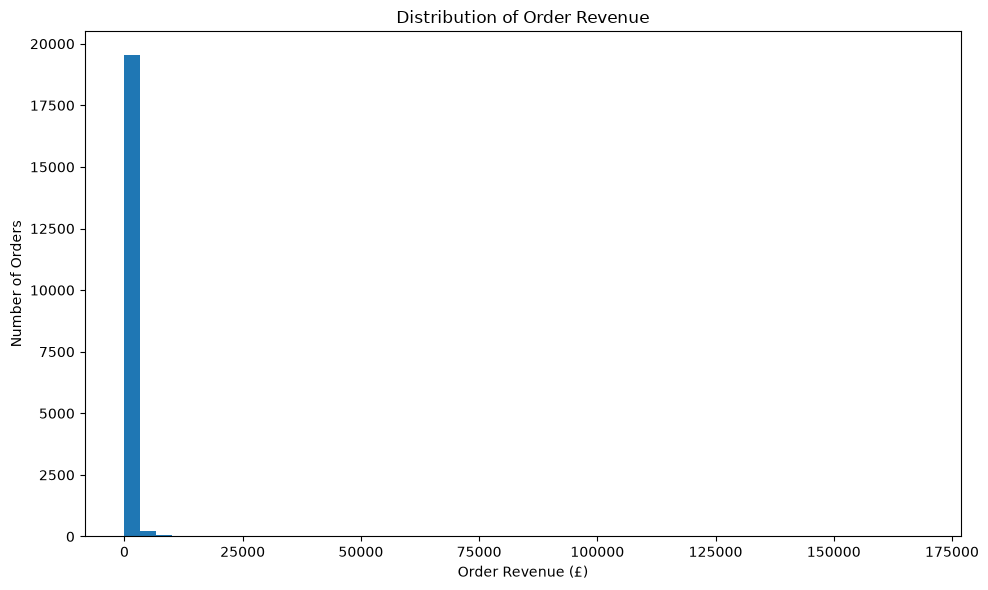

In [73]:
plt.figure(figsize=(10, 6))

plt.hist(
    order_summary["Order_Revenue"],
    bins=50
)

plt.title("Distribution of Order Revenue")
plt.xlabel("Order Revenue (£)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

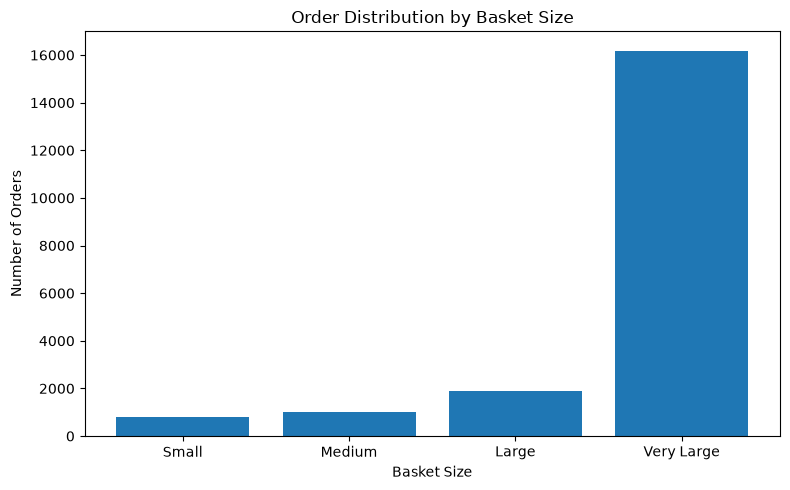

In [74]:
basket_counts = (
    order_summary["Basket_Size"]
    .value_counts()
    .reindex(
        ["Small", "Medium", "Large", "Very Large"]
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    basket_counts.index,
    basket_counts.values
)

plt.title("Order Distribution by Basket Size")
plt.xlabel("Basket Size")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

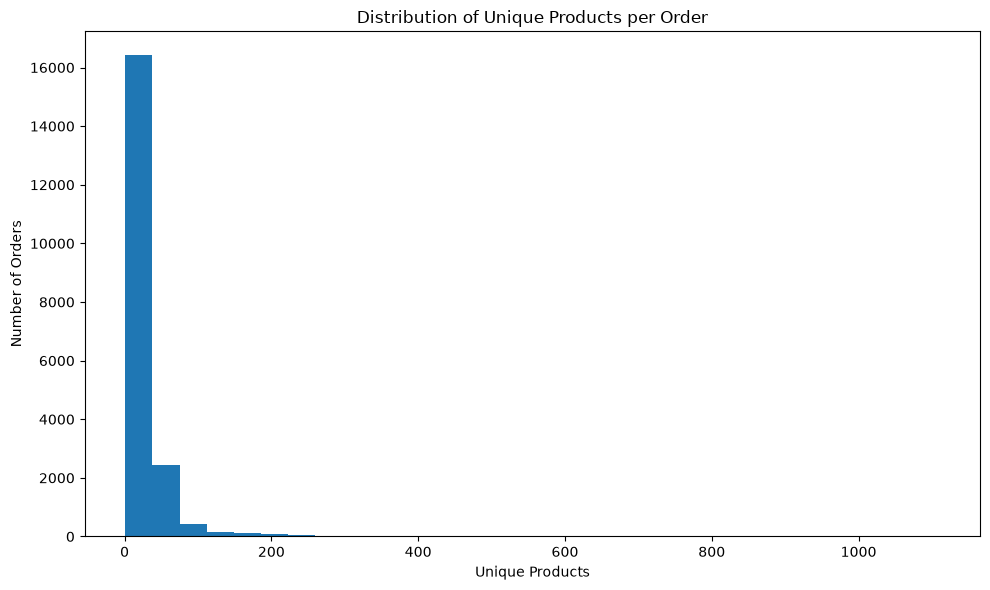

In [75]:
plt.figure(figsize=(10, 6))

plt.hist(
    order_summary["Unique_Products"],
    bins=30
)

plt.title("Distribution of Unique Products per Order")
plt.xlabel("Unique Products")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [76]:
order_business_table = order_summary[
    [
        "Invoice",
        "Order_Revenue",
        "Units",
        "Unique_Products",
        "Average_Item_Value",
        "Customer_ID",
        "Country",
        "Order_Date",
        "Basket_Size"
    ]
].copy()

order_business_table.head(20)

,Invoice,Order_Revenue,Units,Unique_Products,Average_Item_Value,Customer_ID,Country,Order_Date,Basket_Size
0,536365,139.12,40,7,3.478000,17850.0,United Kingdom,2010-12-01 08:26:00,Large
1,536366,22.20,12,2,1.850000,17850.0,United Kingdom,2010-12-01 08:28:00,Medium
2,536367,278.73,83,12,3.358193,13047.0,United Kingdom,2010-12-01 08:34:00,Very Large
3,536368,70.05,15,4,4.670000,13047.0,United Kingdom,2010-12-01 08:34:00,Medium
4,536369,17.85,3,1,5.950000,13047.0,United Kingdom,2010-12-01 08:35:00,Small
5,536370,855.86,449,20,1.906147,12583.0,France,2010-12-01 08:45:00,Very Large
6,536371,204.00,80,1,2.550000,13748.0,United Kingdom,2010-12-01 09:00:00,Very Large
7,536372,22.20,12,2,1.850000,17850.0,United Kingdom,2010-12-01 09:01:00,Medium
8,536373,259.86,88,16,2.952955,17850.0,United Kingdom,2010-12-01 09:02:00,Very Large
9,536374,350.40,32,1,10.950000,15100.0,United Kingdom,2010-12-01 09:09:00,Large


In [77]:
order_business_table.to_csv(
    "../data/order_analytics.csv",
    index=False
)

print("Saved:", "../data/order_analytics.csv")
print("Shape:", order_business_table.shape)

Saved: ../data/order_analytics.csv
Shape: (19865, 9)


## Business Feature Engineering

This section creates customer, order, and product-level features from the cleaned transaction data and business analytics. These features will be used later for customer segmentation, machine learning, and downstream AI applications.

In [78]:
customer_features = (
    customer_df
    .groupby("Customer ID")
    .agg(
        Total_Orders=("Invoice", "nunique"),
        Total_Revenue=("Revenue", "sum"),
        Total_Units=("Quantity", "sum"),
        Unique_Products=("StockCode", "nunique"),
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_features.head()

,Customer ID,Total_Orders,Total_Revenue,Total_Units,Unique_Products,First_Purchase,Last_Purchase
0,12346.0,1,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,7,4310.00,2458,103,2010-12-07 14:57:00,2011-12-07 15:52:00
2,12348.0,4,1797.24,2341,22,2010-12-16 19:09:00,2011-09-25 13:13:00
3,12349.0,1,1757.55,631,73,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350.0,1,334.40,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00


In [79]:
analysis_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_features["Recency_Days"] = (
    analysis_date - customer_features["Last_Purchase"]
).dt.days

customer_features["Customer_Lifetime_Days"] = (
    customer_features["Last_Purchase"] -
    customer_features["First_Purchase"]
).dt.days

customer_features.head()

,Customer ID,Total_Orders,Total_Revenue,Total_Units,Unique_Products,First_Purchase,Last_Purchase,Recency_Days,Customer_Lifetime_Days
0,12346.0,1,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,326,0
1,12347.0,7,4310.00,2458,103,2010-12-07 14:57:00,2011-12-07 15:52:00,2,365
2,12348.0,4,1797.24,2341,22,2010-12-16 19:09:00,2011-09-25 13:13:00,75,282
3,12349.0,1,1757.55,631,73,2011-11-21 09:51:00,2011-11-21 09:51:00,19,0
4,12350.0,1,334.40,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,310,0


In [80]:
customer_features["Average_Order_Value"] = (
    customer_features["Total_Revenue"] /
    customer_features["Total_Orders"]
)

customer_features["Average_Units_Per_Order"] = (
    customer_features["Total_Units"] /
    customer_features["Total_Orders"]
)

customer_features["Average_Products_Per_Order"] = (
    customer_features["Unique_Products"] /
    customer_features["Total_Orders"]
)

customer_features.head()

,Customer ID,Total_Orders,Total_Revenue,Total_Units,Unique_Products,First_Purchase,Last_Purchase,Recency_Days,Customer_Lifetime_Days,Average_Order_Value,Average_Units_Per_Order,Average_Products_Per_Order
0,12346.0,1,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,326,0,77183.600000,74215.000000,1.000000
1,12347.0,7,4310.00,2458,103,2010-12-07 14:57:00,2011-12-07 15:52:00,2,365,615.714286,351.142857,14.714286
2,12348.0,4,1797.24,2341,22,2010-12-16 19:09:00,2011-09-25 13:13:00,75,282,449.310000,585.250000,5.500000
3,12349.0,1,1757.55,631,73,2011-11-21 09:51:00,2011-11-21 09:51:00,19,0,1757.550000,631.000000,73.000000
4,12350.0,1,334.40,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,310,0,334.400000,197.000000,17.000000


In [81]:
customer_features["Orders_Per_Month"] = (
    customer_features["Total_Orders"] /
    (customer_features["Customer_Lifetime_Days"] / 30 + 1)
)

customer_features.head()

,Customer ID,Total_Orders,Total_Revenue,Total_Units,Unique_Products,First_Purchase,Last_Purchase,Recency_Days,Customer_Lifetime_Days,Average_Order_Value,Average_Units_Per_Order,Average_Products_Per_Order,Orders_Per_Month
0,12346.0,1,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,326,0,77183.600000,74215.000000,1.000000,1.000000
1,12347.0,7,4310.00,2458,103,2010-12-07 14:57:00,2011-12-07 15:52:00,2,365,615.714286,351.142857,14.714286,0.531646
2,12348.0,4,1797.24,2341,22,2010-12-16 19:09:00,2011-09-25 13:13:00,75,282,449.310000,585.250000,5.500000,0.384615
3,12349.0,1,1757.55,631,73,2011-11-21 09:51:00,2011-11-21 09:51:00,19,0,1757.550000,631.000000,73.000000,1.000000
4,12350.0,1,334.40,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,310,0,334.400000,197.000000,17.000000,1.000000


In [82]:
customer_features["Revenue_Segment"] = pd.qcut(
    customer_features["Total_Revenue"].rank(method="first"),
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

customer_features["Revenue_Segment"].value_counts()

Revenue_Segment
Low          1084
Medium       1084
Very High    1084
High         1083
Name: count, dtype: int64

In [83]:
customer_features["Activity_Segment"] = pd.cut(
    customer_features["Recency_Days"],
    bins=[-1, 30, 90, 180, float("inf")],
    labels=[
        "Active",
        "Recently Inactive",
        "At Risk",
        "Inactive"
    ]
)

customer_features["Activity_Segment"].value_counts()

Activity_Segment
Active               1647
Recently Inactive    1240
Inactive              862
At Risk               586
Name: count, dtype: int64

In [84]:
customer_features[
    [
        "Total_Orders",
        "Total_Revenue",
        "Total_Units",
        "Unique_Products",
        "Recency_Days",
        "Customer_Lifetime_Days",
        "Average_Order_Value",
        "Average_Units_Per_Order",
        "Average_Products_Per_Order",
        "Orders_Per_Month"
    ]
].describe()

,Total_Orders,Total_Revenue,Total_Units,Unique_Products,Recency_Days,Customer_Lifetime_Days,Average_Order_Value,Average_Units_Per_Order,Average_Products_Per_Order,Orders_Per_Month
count,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000
mean,4.260208,2037.787074,1186.867359,61.498270,92.678662,130.343945,417.439578,254.013039,18.774670,0.900814
std,7.659946,8966.232164,5041.257672,85.324636,100.203903,132.067521,1797.164600,1314.773092,17.530989,0.794857
min,1.000000,3.750000,1.000000,1.000000,1.000000,0.000000,3.750000,1.000000,0.200000,0.151899
25%,1.000000,306.290000,159.500000,16.000000,18.000000,0.000000,177.821161,92.500000,8.000000,0.529412
50%,2.000000,668.560000,378.000000,35.000000,51.000000,92.000000,291.620000,161.000000,14.000000,1.000000
75%,5.000000,1651.605000,989.500000,77.000000,143.000000,252.000000,428.109583,270.708333,24.000000,1.000000
max,206.000000,280206.020000,196915.000000,1786.000000,374.000000,373.000000,84236.250000,74215.000000,259.000000,32.903226


In [85]:
customer_features.sort_values(
    "Total_Revenue",
    ascending=False
).head(20)

,Customer ID,Total_Orders,Total_Revenue,Total_Units,Unique_Products,First_Purchase,Last_Purchase,Recency_Days,Customer_Lifetime_Days,Average_Order_Value,Average_Units_Per_Order,Average_Products_Per_Order,Orders_Per_Month,Revenue_Segment,Activity_Segment
1689,14646.0,73,280206.02,196915,700,2010-12-20 10:09:00,2011-12-08 12:12:00,2,353,3838.438630,2697.465753,9.589041,5.718016,Very High,Active
4198,18102.0,60,259657.30,64124,150,2010-12-07 16:42:00,2011-12-09 11:50:00,1,366,4327.621667,1068.733333,2.500000,4.545455,Very High,Active
3726,17450.0,46,194390.79,69973,124,2010-12-07 09:23:00,2011-12-01 13:29:00,8,359,4225.886739,1521.152174,2.695652,3.547558,Very High,Active
3007,16446.0,2,168472.50,80997,3,2011-05-18 09:52:00,2011-12-09 09:15:00,1,204,84236.250000,40498.500000,1.500000,0.256410,Very High,Active
1879,14911.0,199,140336.83,80238,1786,2010-12-01 14:05:00,2011-12-08 15:54:00,1,372,705.210201,403.206030,8.974874,14.850746,Very High,Active
55,12415.0,21,124914.53,77374,444,2011-01-06 11:12:00,2011-11-15 14:22:00,24,313,5948.310952,3684.476190,21.142857,1.836735,Very High,Active
1333,14156.0,55,117210.08,57768,714,2010-12-03 11:48:00,2011-11-30 10:54:00,10,361,2131.092364,1050.327273,12.981818,4.219949,Very High,Active
3769,17511.0,31,91062.38,64549,453,2010-12-01 10:19:00,2011-12-07 10:12:00,3,370,2937.496129,2082.225806,14.612903,2.325000,Very High,Active
2701,16029.0,63,80850.84,40108,44,2010-12-01 09:57:00,2011-11-01 10:27:00,39,335,1283.346667,636.634921,0.698413,5.178082,Very High,Recently Inactive
0,12346.0,1,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,326,0,77183.600000,74215.000000,1.000000,1.000000,Very High,Inactive


In [86]:
customer_features.sort_values(
    "Total_Orders",
    ascending=False
).head(20)

,Customer ID,Total_Orders,Total_Revenue,Total_Units,Unique_Products,First_Purchase,Last_Purchase,Recency_Days,Customer_Lifetime_Days,Average_Order_Value,Average_Units_Per_Order,Average_Products_Per_Order,Orders_Per_Month,Revenue_Segment,Activity_Segment
326,12748.0,206,31654.78,25052,1767,2010-12-01 12:48:00,2011-12-09 12:20:00,1,372,153.663981,121.611650,8.577670,15.373134,Very High,Active
1879,14911.0,199,140336.83,80238,1786,2010-12-01 14:05:00,2011-12-08 15:54:00,1,372,705.210201,403.206030,8.974874,14.850746,Very High,Active
4008,17841.0,124,40495.99,22816,1322,2010-12-01 14:41:00,2011-12-08 12:07:00,2,371,326.580565,184.000000,10.661290,9.276808,Very High,Active
562,13089.0,97,58762.08,31025,636,2010-12-05 10:27:00,2011-12-07 09:02:00,3,366,605.794639,319.845361,6.556701,7.348485,Very High,Active
1661,14606.0,92,12061.15,6186,818,2010-12-01 16:57:00,2011-12-08 19:28:00,1,372,131.099457,67.239130,8.891304,6.865672,Very High,Active
2176,15311.0,91,60632.75,38147,567,2010-12-01 09:41:00,2011-12-09 12:00:00,1,373,666.293956,419.197802,6.230769,6.774194,Very High,Active
481,12971.0,86,11189.91,9289,94,2010-12-02 16:42:00,2011-12-06 12:20:00,4,368,130.115233,108.011628,1.093023,6.482412,Very High,Active
1689,14646.0,73,280206.02,196915,700,2010-12-20 10:09:00,2011-12-08 12:12:00,2,353,3838.438630,2697.465753,9.589041,5.718016,Very High,Active
2701,16029.0,63,80850.84,40108,44,2010-12-01 09:57:00,2011-11-01 10:27:00,39,335,1283.346667,636.634921,0.698413,5.178082,Very High,Recently Inactive
795,13408.0,62,28117.04,16232,234,2010-12-01 10:39:00,2011-12-08 09:05:00,2,371,453.500645,261.806452,3.774194,4.638404,Very High,Active


In [87]:
product_features = (
    sales_df
    .groupby("StockCode")
    .agg(
        Product_Name=("Description", "first"),
        Total_Units_Sold=("Quantity", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique"),
        Average_Price=("Price", "mean")
    )
    .reset_index()
)

product_features.head()

,StockCode,Product_Name,Total_Units_Sold,Total_Revenue,Orders,Customers,Average_Price
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,71,40,1.086620
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,22,19,0.410909
2,10120,DOGGY RUBBER,192,40.32,29,25,0.210000
3,10123C,HEARTS WRAPPING TAPE,5,3.25,3,3,0.650000
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16,6.72,5,5,0.420000


In [88]:
product_features["Revenue_Per_Order"] = (
    product_features["Total_Revenue"] /
    product_features["Orders"]
)

product_features["Units_Per_Order"] = (
    product_features["Total_Units_Sold"] /
    product_features["Orders"]
)

product_features["Customer_Penetration"] = (
    product_features["Customers"] /
    customer_features["Customer ID"].nunique() * 100
)

product_features.head()

,StockCode,Product_Name,Total_Units_Sold,Total_Revenue,Orders,Customers,Average_Price,Revenue_Per_Order,Units_Per_Order,Customer_Penetration
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,71,40,1.086620,10.702676,12.112676,0.922722
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,22,19,0.410909,5.413182,13.772727,0.438293
2,10120,DOGGY RUBBER,192,40.32,29,25,0.210000,1.390345,6.620690,0.576701
3,10123C,HEARTS WRAPPING TAPE,5,3.25,3,3,0.650000,1.083333,1.666667,0.069204
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16,6.72,5,5,0.420000,1.344000,3.200000,0.115340


In [89]:
product_features["Revenue_Segment"] = pd.qcut(
    product_features["Total_Revenue"].rank(method="first"),
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

product_features["Revenue_Segment"].value_counts()

Revenue_Segment
Low          980
Very High    980
Medium       979
High         979
Name: count, dtype: int64

In [90]:
customer_feature_table = customer_features[
    [
        "Customer ID",
        "Total_Orders",
        "Total_Revenue",
        "Total_Units",
        "Unique_Products",
        "Recency_Days",
        "Customer_Lifetime_Days",
        "Average_Order_Value",
        "Average_Units_Per_Order",
        "Average_Products_Per_Order",
        "Orders_Per_Month",
        "Revenue_Segment",
        "Activity_Segment"
    ]
].copy()

customer_feature_table.head()

,Customer ID,Total_Orders,Total_Revenue,Total_Units,Unique_Products,Recency_Days,Customer_Lifetime_Days,Average_Order_Value,Average_Units_Per_Order,Average_Products_Per_Order,Orders_Per_Month,Revenue_Segment,Activity_Segment
0,12346.0,1,77183.60,74215,1,326,0,77183.600000,74215.000000,1.000000,1.000000,Very High,Inactive
1,12347.0,7,4310.00,2458,103,2,365,615.714286,351.142857,14.714286,0.531646,Very High,Active
2,12348.0,4,1797.24,2341,22,75,282,449.310000,585.250000,5.500000,0.384615,Very High,Recently Inactive
3,12349.0,1,1757.55,631,73,19,0,1757.550000,631.000000,73.000000,1.000000,Very High,Active
4,12350.0,1,334.40,197,17,310,0,334.400000,197.000000,17.000000,1.000000,Medium,Inactive


In [91]:
product_feature_table = product_features[
    [
        "StockCode",
        "Product_Name",
        "Total_Units_Sold",
        "Total_Revenue",
        "Orders",
        "Customers",
        "Average_Price",
        "Revenue_Per_Order",
        "Units_Per_Order",
        "Customer_Penetration",
        "Revenue_Segment"
    ]
].copy()

product_feature_table.head()

,StockCode,Product_Name,Total_Units_Sold,Total_Revenue,Orders,Customers,Average_Price,Revenue_Per_Order,Units_Per_Order,Customer_Penetration,Revenue_Segment
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,71,40,1.086620,10.702676,12.112676,0.922722,High
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,22,19,0.410909,5.413182,13.772727,0.438293,Low
2,10120,DOGGY RUBBER,192,40.32,29,25,0.210000,1.390345,6.620690,0.576701,Low
3,10123C,HEARTS WRAPPING TAPE,5,3.25,3,3,0.650000,1.083333,1.666667,0.069204,Low
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16,6.72,5,5,0.420000,1.344000,3.200000,0.115340,Low


In [92]:
customer_feature_table.to_csv(
    "../data/customer_features.csv",
    index=False
)

product_feature_table.to_csv(
    "../data/product_features.csv",
    index=False
)

print("Customer features:", customer_feature_table.shape)
print("Product features:", product_feature_table.shape)
print("Saved customer_features.csv")
print("Saved product_features.csv")

Customer features: (4335, 13)
Product features: (3918, 11)
Saved customer_features.csv
Saved product_features.csv


In [93]:
print("Customer feature nulls:")
print(customer_feature_table.isna().sum())

print("\nProduct feature nulls:")
print(product_feature_table.isna().sum())

Customer feature nulls:
Customer ID                   0
Total_Orders                  0
Total_Revenue                 0
Total_Units                   0
Unique_Products               0
Recency_Days                  0
Customer_Lifetime_Days        0
Average_Order_Value           0
Average_Units_Per_Order       0
Average_Products_Per_Order    0
Orders_Per_Month              0
Revenue_Segment               0
Activity_Segment              0
dtype: int64

Product feature nulls:
StockCode               0
Product_Name            0
Total_Units_Sold        0
Total_Revenue           0
Orders                  0
Customers               0
Average_Price           0
Revenue_Per_Order       0
Units_Per_Order         0
Customer_Penetration    0
Revenue_Segment         0
dtype: int64


## Business Insights and Feature Review

This section summarizes the main business patterns identified during the analytics stage and reviews the engineered features before they are used in downstream machine learning tasks.

In [94]:
total_revenue = sales_df["Revenue"].sum()
total_units = sales_df["Quantity"].sum()
total_orders = sales_df["Invoice"].nunique()
total_customers = sales_df["Customer ID"].nunique()
total_products = sales_df["StockCode"].nunique()

print("Total Revenue: £{:,.2f}".format(total_revenue))
print("Total Units Sold: {:,.0f}".format(total_units))
print("Total Orders: {:,.0f}".format(total_orders))
print("Identifiable Customers: {:,.0f}".format(total_customers))
print("Unique Products: {:,.0f}".format(total_products))

Total Revenue: £10,539,552.83
Total Units Sold: 5,565,433
Total Orders: 19,865
Identifiable Customers: 4,335
Unique Products: 3,918


In [95]:
top_10_revenue = (
    product_features
    .sort_values("Total_Revenue", ascending=False)
    .head(10)["Total_Revenue"]
    .sum()
)

top_10_revenue_share = (
    top_10_revenue /
    product_features["Total_Revenue"].sum() * 100
)

print(
    "Top 10 products revenue share: {:.2f}%".format(
        top_10_revenue_share
    )
)

Top 10 products revenue share: 10.80%


In [96]:
top_10_customers_revenue = (
    customer_features
    .sort_values("Total_Revenue", ascending=False)
    .head(10)["Total_Revenue"]
    .sum()
)

top_10_customer_share = (
    top_10_customers_revenue /
    customer_features["Total_Revenue"].sum() * 100
)

print(
    "Top 10 customers revenue share: {:.2f}%".format(
        top_10_customer_share
    )
)

Top 10 customers revenue share: 17.37%


In [97]:
uk_revenue = country_summary.loc[
    country_summary["Country"] == "United Kingdom",
    "Revenue"
].iloc[0]

international_revenue = (
    country_summary[
        country_summary["Country"] != "United Kingdom"
    ]["Revenue"].sum()
)

international_share = (
    international_revenue /
    country_summary["Revenue"].sum() * 100
)

print("UK Revenue: £{:,.2f}".format(uk_revenue))
print(
    "International Revenue: £{:,.2f}".format(
        international_revenue
    )
)
print(
    "International Revenue Share: {:.2f}%".format(
        international_share
    )
)

UK Revenue: £8,941,988.24
International Revenue: £1,597,564.59
International Revenue Share: 15.16%


In [98]:
activity_summary = (
    customer_features
    .groupby("Activity_Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Revenue=("Total_Revenue", "sum"),
        Average_Revenue=("Total_Revenue", "mean")
    )
    .reset_index()
)

activity_summary["Revenue_Share_Pct"] = (
    activity_summary["Revenue"] /
    activity_summary["Revenue"].sum() * 100
)

activity_summary

,Activity_Segment,Customers,Revenue,Average_Revenue,Revenue_Share_Pct
0,Active,1647,6224125.470,3779.068288,70.458020
1,Recently Inactive,1240,1584214.253,1277.592140,17.933539
2,At Risk,586,467247.210,797.350188,5.289307
3,Inactive,862,558220.031,647.587043,6.319133


In [99]:
customer_model_features = [
    "Total_Orders",
    "Total_Revenue",
    "Total_Units",
    "Unique_Products",
    "Recency_Days",
    "Customer_Lifetime_Days",
    "Average_Order_Value",
    "Average_Units_Per_Order",
    "Average_Products_Per_Order",
    "Orders_Per_Month"
]

product_model_features = [
    "Total_Units_Sold",
    "Total_Revenue",
    "Orders",
    "Customers",
    "Average_Price",
    "Revenue_Per_Order",
    "Units_Per_Order",
    "Customer_Penetration"
]

print("Customer ML features:")
print(customer_model_features)

print("\nProduct ML features:")
print(product_model_features)

Customer ML features:
['Total_Orders', 'Total_Revenue', 'Total_Units', 'Unique_Products', 'Recency_Days', 'Customer_Lifetime_Days', 'Average_Order_Value', 'Average_Units_Per_Order', 'Average_Products_Per_Order', 'Orders_Per_Month']

Product ML features:
['Total_Units_Sold', 'Total_Revenue', 'Orders', 'Customers', 'Average_Price', 'Revenue_Per_Order', 'Units_Per_Order', 'Customer_Penetration']


In [101]:
print("===== STAGE 5 VALIDATION =====")

print("\nCustomer features:")
print(customer_feature_table.shape)

print("\nProduct features:")
print(product_feature_table.shape)

print("\nOrder analytics:")
print(order_business_table.shape)

print("\nAll customer feature values non-null:",
    customer_feature_table[customer_model_features].notna().all().all())

print("All product feature values non-null:",
    product_feature_table[product_model_features].notna().all().all())

===== STAGE 5 VALIDATION =====

Customer features:
(4335, 13)

Product features:
(3918, 11)

Order analytics:
(19865, 9)

All customer feature values non-null: True
All product feature values non-null: True


In [102]:
print("===== COMMERCEIQ STAGE 5 SUMMARY =====")

print(
    f"""
Revenue: £{total_revenue:,.2f}
Orders: {total_orders:,}
Customers: {total_customers:,}
Products: {total_products:,}

UK Revenue Share: {uk_revenue / country_summary["Revenue"].sum() * 100:.2f}%
International Revenue Share: {international_share:.2f}%

Top 10 Product Revenue Share: {top_10_revenue_share:.2f}%
Top 10 Customer Revenue Share: {top_10_customer_share:.2f}%
"""
)

===== COMMERCEIQ STAGE 5 SUMMARY =====

Revenue: £10,539,552.83
Orders: 19,865
Customers: 4,335
Products: 3,918

UK Revenue Share: 84.84%
International Revenue Share: 15.16%

Top 10 Product Revenue Share: 10.80%
Top 10 Customer Revenue Share: 17.37%

